# Getting started

`journalfig` encodes what Nature, APS, and Elsevier actually document about figures — column widths,
font sizes, panel-label conventions, minimum line weights, accepted file formats — so a figure can be
retargeted from one journal to another by changing a single string.

This notebook covers the parts that are not specific to any one kind of plot: picking a theme, exact
sizing, saving, and checking compliance. The other notebooks in this folder each take one kind of
figure:

| notebook | covers |
|---|---|
| `01_line_plots.ipynb` | line plots, the colour/linestyle cycle, greyscale safety |
| `02_scatter_plots.ipynb` | markers, the points-versus-points² trap, error bars |
| `03_histograms.ipynb` | distributions, outlines, shared bins, hatching |
| `04_heatmaps.ipynb` | `imshow`, `pcolormesh`, colormaps, colorbars |
| `05_multipanel_figures.ipynb` | multi-panel layouts, and how to make them look professional |
| `06_reading_and_fitting.ipynb` | reading a data file, fitting it, showing the uncertainty |
| `07_boxplots.ipynb` | the five-number summary, whisker conventions, comparing groups |

All data here is synthetic and all axis labels are deliberately generic — this notebook is about how a
figure is built and styled, not about any particular measurement.

In [1]:
%matplotlib inline

# Jupyter crops every inline preview with bbox_inches="tight". That defeats the exact column widths
# this package exists to guarantee, and because the themes sit the axes close to the canvas edge, the
# crop slices through the top and right spines. Turn it off so previews match the files jf.save() writes.
%config InlineBackend.print_figure_kwargs = {"bbox_inches": None}

# jf.save() reports what it wrote through the "journalfig" logger instead of printing. Raise that one
# logger -- a blanket logging.basicConfig(level="INFO") also switches on fontTools, which logs a dozen
# subsetting lines per PDF.
import logging

logging.basicConfig(format="%(message)s")
logging.getLogger("journalfig").setLevel(logging.INFO)

import numpy as np
import matplotlib.pyplot as plt

import journalfig as jf

# The themes render previews at 600 dpi, which makes every embedded image in a notebook large. This
# only touches the on-screen preview; jf.save() exports at savefig.dpi regardless.
PREVIEW_DPI = 150


def preview(journal, **kwargs):
    """Apply a theme, then drop the on-screen DPI so this notebook stays light."""
    jf.use(journal, **kwargs)
    plt.rcParams["figure.dpi"] = PREVIEW_DPI


rng = np.random.default_rng(0)
print("journalfig", jf.__version__, "| themes:", jf.JOURNALS)

journalfig 0.4.0 | themes: ('nature', 'aps', 'elsevier', 'iop', 'aip', 'acs', 'rsc', 'ieee', 'plos', 'wiley', 'pnas', 'science')


## Pick a theme by journal name

`jf.use()` takes a theme key or any alias the package knows, so you can name the journal you are
actually submitting to.

In [2]:
for name in ["Nature", "npj", "PRB", "Physical Review Letters", "Acta Materialia", "JNCS"]:
    print(f"{name:28s} -> {jf.resolve(name)}")

Nature                       -> nature
npj                          -> nature
PRB                          -> aps
Physical Review Letters      -> aps
Acta Materialia              -> elsevier
JNCS                         -> elsevier


## What each publisher requires

Every number below is read from the publisher's own document. `jf.source()` reports which document,
and when its numbers were last checked — a specification is only as trustworthy as that date.

In [3]:
for journal in jf.JOURNALS:
    spec = jf.get_spec(journal)
    widths = ", ".join(f"{name} {mm:.0f} mm" for name, mm in sorted(spec.widths_mm.items()))
    print(f"{spec.name}")
    print(f"  widths      : {widths}")
    faces = ", ".join(spec.font_families) or "no typeface stated"
    print(f"  base font   : {spec.font_sizes['base']:.0f} pt, {faces}")
    print(f"  panel label : {spec.panel_label_fmt.format('a')} at {spec.panel_label_pt:.0f} pt")
    print(f"  writes      : {', '.join(f.upper() for f in spec.formats)}")
    print(f"  accepts     : {', '.join(f.upper() for f in spec.submission_formats)}")
    print(f"  source      : {jf.source(journal)}")

Nature Portfolio
  widths      : double 183 mm, onehalf 120 mm, onehalf_wide 136 mm, single 89 mm
  base font   : 7 pt, Arial, Helvetica, Helvetica Neue
  panel label : a at 8 pt
  writes      : PDF, SVG, PNG
  accepts     : PDF
  source      : Nature Portfolio, Guide to Preparing Final Artwork (retrieved 2026-07-28)
American Physical Society (PRB/PRL)
  widths      : double 178 mm, onehalf 135 mm, single 86 mm
  base font   : 9 pt, Times New Roman, Times
  panel label : (a) at 9 pt
  writes      : PDF, SVG, PNG
  accepts     : PDF, EPS
  source      : APS Journals Style Guide for Authors, November 2024 (retrieved 2026-07-28)
Elsevier
  widths      : double 190 mm, onehalf 140 mm, single 90 mm
  base font   : 7 pt, Arial, Times New Roman
  panel label : (a) at 8 pt
  writes      : PDF, SVG, PNG
  accepts     : PDF, EPS, TIFF, JPEG, JPG
  source      : Elsevier, Artwork sizing (retrieved 2026-07-28)
IOP Publishing
  widths      : double 150 mm, single 85 mm
  base font   : 8 pt, Times, 

## Your first figure

Use `jf.subplots()` rather than `plt.subplots(figsize=...)`. It pins the exact size, which a plain
`plt.subplots` loses: interactive backends round a new figure to whole device pixels, turning a
requested 183.0 mm into 182.88 mm.

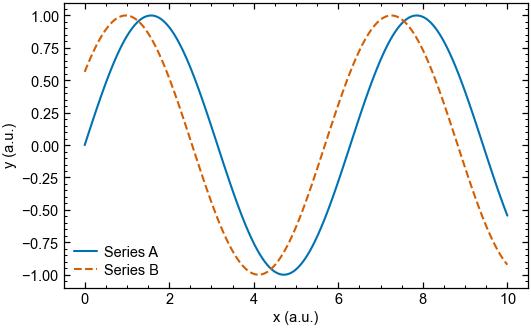

In [4]:
preview("elsevier")

x = np.linspace(0, 10, 200)
fig, ax = jf.subplots("elsevier", width="single")
ax.plot(x, np.sin(x), label="Series A")
ax.plot(x, np.sin(x + 0.6), label="Series B")
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
ax.legend()

## Exact widths, every time

`width=` takes a layout name from the journal's spec, or an explicit width in millimetres.

In [5]:
for journal in jf.JOURNALS:
    for name in sorted(jf.get_spec(journal).widths_mm):
        w_in, h_in = jf.figsize(journal, name)
        print(f"{journal:9s} {name:13s} {w_in * 25.4:7.2f} x {h_in * 25.4:6.2f} mm")

nature    double         183.00 x 113.10 mm
nature    onehalf        120.00 x  74.16 mm
nature    onehalf_wide   136.00 x  84.05 mm
nature    single          89.00 x  55.01 mm
aps       double         177.80 x 109.89 mm
aps       onehalf        134.94 x  83.40 mm
aps       single          85.72 x  52.98 mm
elsevier  double         190.00 x 117.43 mm
elsevier  onehalf        140.00 x  86.52 mm
elsevier  single          90.00 x  55.62 mm
iop       double         150.00 x  92.71 mm
iop       single          85.00 x  52.53 mm
aip       double         169.90 x 105.00 mm
aip       single          85.00 x  52.53 mm
acs       double         177.80 x 109.89 mm
acs       single          84.70 x  52.35 mm
rsc       double         171.00 x 105.68 mm
rsc       single          83.00 x  51.30 mm
ieee      double         181.90 x 112.42 mm
ieee      single          88.90 x  54.94 mm
plos      double         190.50 x 117.74 mm
plos      single          66.80 x  41.28 mm
wiley     double         180.00 

Height defaults to the inverse golden ratio. Override it with `ratio=` or `height_mm=` — and for
anything with more than one row you should, because the golden ratio is far too short there.

In [6]:
print("golden      :", [round(v, 3) for v in jf.figsize("aps", "single")])
print("ratio=0.8   :", [round(v, 3) for v in jf.figsize("aps", "single", ratio=0.8)])
print("height_mm=40:", [round(v, 3) for v in jf.figsize("aps", "single", height_mm=40)])

golden      : [3.375, 2.086]
ratio=0.8   : [3.375, 2.7]
height_mm=40: [3.375, 1.575]


## Saving

Every theme writes PDF, SVG and PNG: the file you submit, one to edit in Inkscape or Illustrator, and
one for a talk. Ask for anything else with `formats=`.

Nature Portfolio: 89.0 x 55.0 mm -> figure_01.pdf, figure_01.svg, figure_01.png



  figure_01.pdf             17.5 kB
  figure_01.png             50.2 kB
  figure_01.svg             38.5 kB


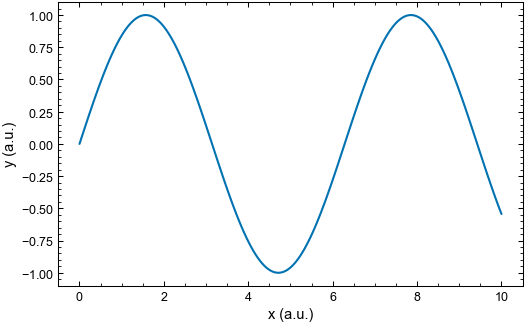

In [7]:
import tempfile
from pathlib import Path

outdir = Path(tempfile.mkdtemp())
preview("nature")

fig, ax = jf.subplots("nature", width="single")
ax.plot(x, np.sin(x))
ax.set_xlabel("x (a.u.)")
ax.set_ylabel("y (a.u.)")
jf.save(fig, outdir / "figure_01")

print()
for path in sorted(outdir.iterdir()):
    print(f"  {path.name:22s} {path.stat().st_size / 1024:7.1f} kB")

The declared width survives into the file — `jf.save()` forces `bbox_inches=None`, because a tight
bounding box crops an 89 mm figure to about 87.9 mm.

Nature Portfolio: 183.0 x 113.1 mm -> width_check.pdf


PDF MediaBox width: 183.0000 mm  (Nature double column is 183 mm)


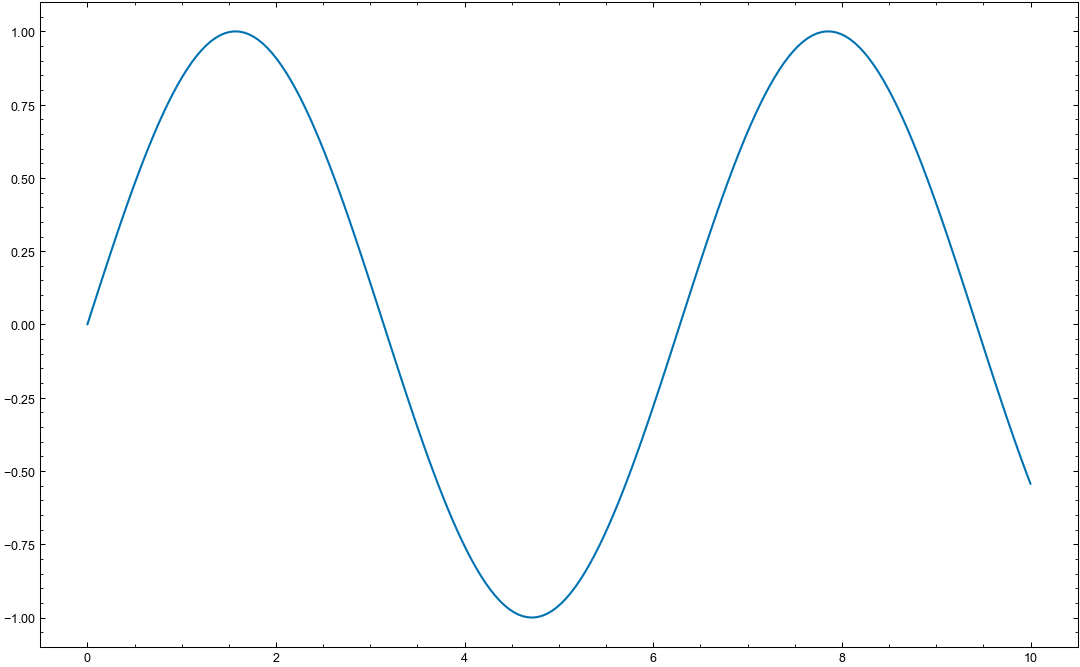

In [8]:
import re

fig, ax = jf.subplots("nature", width="double")
ax.plot(x, np.sin(x))
(pdf_path,) = jf.save(fig, outdir / "width_check", formats=["pdf"], validate=False)

box = re.search(rb"/MediaBox\s*\[([^\]]*)\]", pdf_path.read_bytes()).group(1).split()
width_mm = (float(box[2]) - float(box[0])) / 72 * 25.4
print(f"PDF MediaBox width: {width_mm:.4f} mm  (Nature double column is 183 mm)")

## Compliance checking

`jf.check()` reports what a publisher would object to. The most common one is invisible on screen:
matplotlib shrinks maths sub/superscripts to 0.7x, so a 7 pt Elsevier label renders a subscript at
4.9 pt against a hard 6 pt floor.

In [9]:
jf.use("elsevier")
fig, ax = jf.subplots("elsevier", width="single")
ax.plot(x, np.sin(x))
ax.set_xlabel("$x_{1}$ (a.u.)")
ax.set_ylabel("$y_{2}$ (a.u.)")

for violation in jf.check(fig, warn=False):
    print(violation)
plt.close(fig)

[subscript] '$x_{1}$ (a.u.)' renders sub/superscripts at 4.90 pt (7.0 pt x 0.7), below the 6 pt floor
[subscript] '$y_{2}$ (a.u.)' renders sub/superscripts at 4.90 pt (7.0 pt x 0.7), below the 6 pt floor


The fix is to scale the whole theme up, which `base_size=` does proportionally:

violations: []


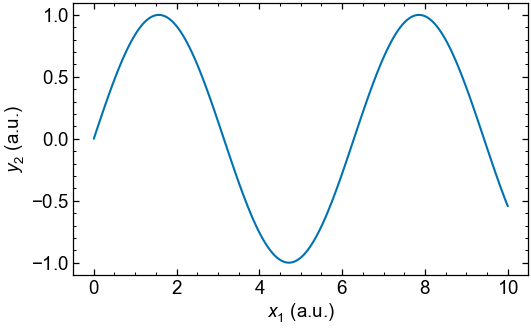

In [10]:
preview("elsevier", base_size=9)
fig, ax = jf.subplots("elsevier", width="single")
ax.plot(x, np.sin(x))
ax.set_xlabel("$x_{1}$ (a.u.)")
ax.set_ylabel("$y_{2}$ (a.u.)")
print("violations:", jf.check(fig, warn=False))

It also catches the one failure that leaves no trace in the figure: **a missing font**. Ask for Arial
on a machine without it and matplotlib silently draws DejaVu Sans instead. `jf.fonts()` shows what
each face really resolved to — `exact` for a face the publisher names, `substitute` for a metrically
compatible stand-in (which passes), `fallback` for anything else.

In [11]:
for journal in jf.JOURNALS:
    jf.use(journal)
    status = jf.fonts()["text"]
    print(f"{journal:9s} {status.resolved:20s} {status.status}")

nature    Arial                exact


aps       Times New Roman      exact
elsevier  Arial                exact
iop       Times New Roman      fallback
aip       Times New Roman      unrestricted
acs       Arial                exact
rsc       Arial                exact
ieee      Arial                exact
plos      Arial                exact
wiley     Arial                unrestricted
pnas      Arial                exact
science   Arial                exact


## Temporary themes

`jf.context()` restores the previous rcParams on exit, and the themes are registered with matplotlib
itself, so plain `plt.style.use` works too after importing the package.

In [12]:
jf.use("nature")
print("outside:", plt.rcParams["font.size"])
with jf.context("aps"):
    print("inside :", plt.rcParams["font.size"])
print("after  :", plt.rcParams["font.size"])

print("registered styles:", [s for s in plt.style.available if s in jf.JOURNALS])

outside: 7.0
inside : 9.0
after  : 7.0
registered styles: ['acs', 'aip', 'aps', 'elsevier', 'ieee', 'iop', 'nature', 'plos', 'pnas', 'rsc', 'science', 'wiley']
